In [1]:
# Checkpoint B: QuantaFlex ETF Data Preparation

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
tickers = ["NVDA", "AGG", "ACWI", "GLD", "DBC", "BIL", "SPY"]
start_date = "2008-01-01"
end_date = "2024-12-31"

In [5]:
price_data = {}

for ticker in tickers:
    try:
        df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
        if not df.empty:
            close_series = df["Close"].copy()
            close_series.name = ticker
            price_data[ticker] = close_series
            print(f"{ticker}: success")
        else:
            print(f"{ticker}: no data returned")
    except Exception as e:
        print(f"{ticker}: failed -> {e}")

NVDA: success
AGG: success
ACWI: success
GLD: success
DBC: success
BIL: success
SPY: success


In [6]:
prices = pd.concat(price_data.values(), axis=1).dropna()
prices.head()

Ticker,NVDA,AGG,ACWI,GLD,DBC,BIL,SPY
Date,,,,,,,
2008-03-28,0.451058,60.240574,35.668972,91.879997,30.504240,73.27668,94.377205
2008-03-31,0.453579,60.146790,35.113651,90.410004,29.771803,73.35643,94.707329
2008-04-01,0.481312,59.738014,36.060558,86.860001,29.605341,73.30851,98.037193
2008-04-02,0.466643,59.767441,36.459236,89.269997,30.487597,73.30851,98.101784
2008-04-03,0.457934,59.955616,36.665699,89.419998,30.654053,73.30851,98.345779


In [7]:
log_returns = np.log(prices / prices.shift(1)) * 100
log_returns = log_returns.dropna()
log_returns.head()

Ticker,NVDA,AGG,ACWI,GLD,DBC,BIL,SPY
Date,,,,,,,
2008-03-31,0.557393,-0.155804,-1.569120,-1.612843,-2.430396,0.108775,0.349182
2008-04-01,5.934560,-0.681950,2.660972,-4.005729,-0.560695,-0.065347,3.455554
2008-04-02,-3.095031,0.049247,1.099512,2.736781,2.936515,0.000000,0.065862
2008-04-03,-1.884030,0.314351,0.564687,0.167890,0.544495,0.000000,0.248408
2008-04-04,-6.193925,0.508896,-0.058248,0.923925,0.703469,0.043576,-0.109521


In [8]:
summary_stats = pd.DataFrame({
    "Mean Daily Return (%)": log_returns.mean(),
    "Volatility Daily (%)": log_returns.std(),
    "Min Return (%)": log_returns.min(),
    "Max Return (%)": log_returns.max()
})

summary_stats

,Mean Daily Return (%),Volatility Daily (%),Min Return (%),Max Return (%)
Ticker,,,,
NVDA,0.135595,3.075384,-36.710876,26.087610
AGG,0.010059,0.348280,-7.084631,3.795866
ACWI,0.027938,1.290866,-11.895517,11.701237
GLD,0.022825,1.086438,-9.190507,10.697398
DBC,-0.009333,1.220271,-8.277776,6.648429
BIL,0.003993,0.030122,-0.391731,0.434094
SPY,0.043039,1.257326,-11.588642,13.557741


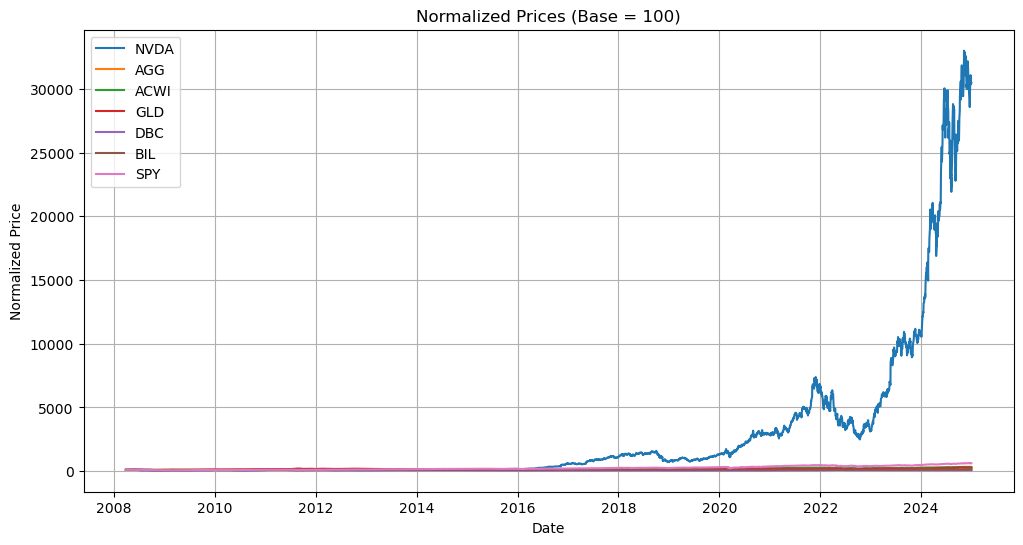

In [9]:
normalized_prices = prices / prices.iloc[0] * 100

plt.figure(figsize=(12, 6))
for col in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[col], label=col)
plt.title("Normalized Prices (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)
plt.show()

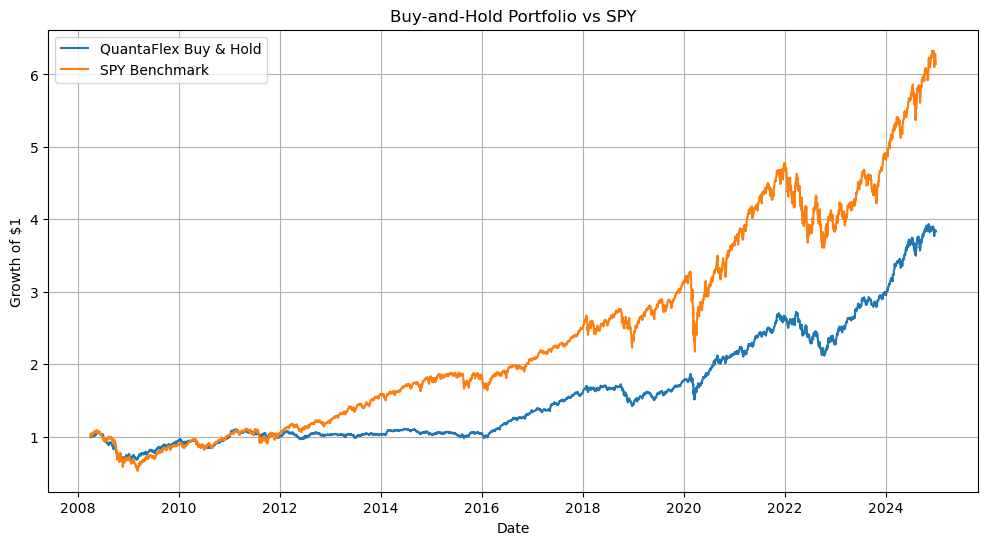

In [10]:
portfolio_assets = ["NVDA", "AGG", "ACWI", "GLD", "DBC", "BIL"]
weights = np.array([1/6] * 6)

portfolio_returns = log_returns[portfolio_assets].dot(weights)
cumulative_portfolio = np.exp(portfolio_returns.cumsum() / 100)
cumulative_spy = np.exp(log_returns["SPY"].cumsum() / 100)

plt.figure(figsize=(12, 6))
plt.plot(cumulative_portfolio.index, cumulative_portfolio, label="QuantaFlex Buy & Hold")
plt.plot(cumulative_spy.index, cumulative_spy, label="SPY Benchmark")
plt.title("Buy-and-Hold Portfolio vs SPY")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
def performance_metrics(returns, benchmark=None):
    ann_return = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    wealth = np.exp(returns.cumsum() / 100)
    running_max = wealth.cummax()
    drawdown = (wealth - running_max) / running_max
    max_dd = drawdown.min()

    results = {
        "Annualized Return (%)": ann_return,
        "Annualized Volatility (%)": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown (%)": max_dd * 100
    }

    if benchmark is not None:
        cov = np.cov(returns, benchmark)[0, 1]
        var_b = np.var(benchmark)
        beta = cov / var_b if var_b != 0 else np.nan
        alpha = ann_return - beta * (benchmark.mean() * 252)
        results["Alpha (%)"] = alpha
        results["Beta"] = beta

    return pd.Series(results)

portfolio_metrics = performance_metrics(portfolio_returns, log_returns["SPY"])
spy_metrics = performance_metrics(log_returns["SPY"])

print("QuantaFlex Buy-and-Hold Metrics")
display(portfolio_metrics)

print("SPY Metrics")
display(spy_metrics)

QuantaFlex Buy-and-Hold Metrics


Annualized Return (%)         8.025280
Annualized Volatility (%)    12.910833
Sharpe Ratio                  0.621593
Max Drawdown (%)            -39.341529
Alpha (%)                     2.644356
Beta                          0.496125
dtype: float64

SPY Metrics


Annualized Return (%)        10.845915
Annualized Volatility (%)    19.959425
Sharpe Ratio                  0.543398
Max Drawdown (%)            -51.481473
dtype: float64

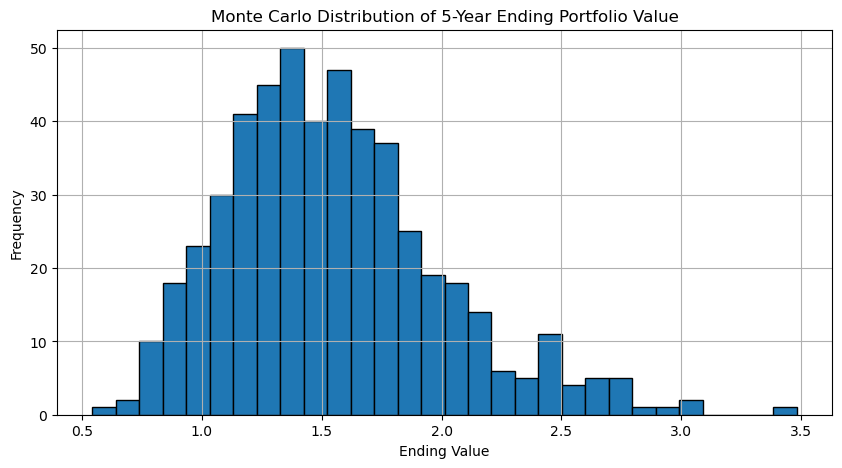

Mean Ending Value: 1.548697659840489
Median Ending Value: 1.5026537198842933


In [12]:
mu = log_returns[portfolio_assets].mean().values
cov = log_returns[portfolio_assets].cov().values

n_days = 252 * 5
n_sims = 500
sim_end_values = []

for _ in range(n_sims):
    simulated = np.random.multivariate_normal(mu, cov, size=n_days)
    sim_portfolio_returns = simulated.dot(weights)
    sim_wealth = np.exp(sim_portfolio_returns.cumsum() / 100)
    sim_end_values.append(sim_wealth[-1])

plt.figure(figsize=(10, 5))
plt.hist(sim_end_values, bins=30, edgecolor="black")
plt.title("Monte Carlo Distribution of 5-Year Ending Portfolio Value")
plt.xlabel("Ending Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

print("Mean Ending Value:", np.mean(sim_end_values))
print("Median Ending Value:", np.median(sim_end_values))